# Top 5 XLK Stationary-Point Backtest

This notebook extends the stationary-point identifier into a simple backtest.

Trading logic:

1. Download yesterday's 1-minute Alpaca data for the top 5 XLK stocks.
2. Identify confirmed local minima and maxima on the EMA-smoothed close.
3. Run trading cycle every minute:
   - **Sell phase first**
   - **Risk/portfolio update phase**
   - **Buy phase**
4. Buy only on **confirmed local minima**.
5. Sell only on:
   - stop-loss,
   - forced end-of-day liquidation,
   - confirmed local maximum **and** price is at least `0.4%` above entry.
6. Position sizing uses ATR-based risk.

Early warnings are calculated for diagnostics but are not plotted and are not used for trades.

In [2]:
# ============================================================
# Cell 1 — Imports and config
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta, timezone
from zoneinfo import ZoneInfo
from dotenv import load_dotenv

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.enums import DataFeed


# -----------------------------
# Alpaca setup
# -----------------------------

load_dotenv()

ALPACA_API_KEY = "PKB2XCLH5BHHHXRV3SB4FPD7DM"
ALPACA_SECRET_KEY = "DcaQGsPCRjfgTRgxVHDpgJrasWBScAoF7Z8aFVE9kjbL"

if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
    raise ValueError(
        "Missing Alpaca keys. Add ALPACA_API_KEY and ALPACA_SECRET_KEY to your .env file."
    )

data_client = StockHistoricalDataClient(
    ALPACA_API_KEY,
    ALPACA_SECRET_KEY
)

NY_TZ = ZoneInfo("America/New_York")

# Top 5 XLK stocks we are testing
SYMBOLS = ["NVDA", "AAPL", "MSFT", "AVGO", "MU"]

DATA_FEED = DataFeed.IEX
# DATA_FEED = DataFeed.SIP  # use this if your Alpaca plan supports SIP


# -----------------------------
# Date settings
# -----------------------------

MANUAL_TARGET_DAY = None
# Example manual override:
# MANUAL_TARGET_DAY = pd.Timestamp("2026-05-19").date()


# -----------------------------
# Stationary-point settings
# -----------------------------

EMA_PRICE_SPAN = 9

SLOPE_LOOKBACK = 3
CURVATURE_LOOKBACK = 3

# Percentage-based thresholds, intentionally not too strict
MIN_ABS_SLOPE = 0.00008          # 0.008%
MIN_ABS_CURVATURE = 0.000025     # 0.0025%

COOLDOWN_MINUTES = 8

IGNORE_BEFORE_TIME = "09:45"
MIN_BARS_BEFORE_SIGNALS = 15


# -----------------------------
# Backtest account settings
# -----------------------------

STARTING_CASH = 1500.00

LAST_BUY_TIME = "15:30"
FORCE_SELL_TIME = "15:55"

MAX_OPEN_POSITIONS = 3
MAX_NEW_BUYS_PER_MINUTE = 2

CASH_BUFFER_FRACTION = 0.05
MIN_POSITION_VALUE = 50.00
MAX_POSITION_FRACTION = 0.25

# Risk budget
RISK_PER_TRADE_PCT = 0.004          # 0.4% account risk per trade
MAX_TOTAL_OPEN_RISK_PCT = 0.015     # 1.5% total open risk cap

# ATR risk sizing
ATR_LOOKBACK = 30
ATR_MULTIPLIER = 2.0
MIN_STOP_LOSS_PCT = 0.006
MAX_STOP_LOSS_PCT = 0.030

# Execution assumptions
SLIPPAGE_BPS = 2
SLIPPAGE_RATE = SLIPPAGE_BPS / 10000

# Sell rule requested:
# Only sell on confirmed max if price is at least 0.4% above bought price.
CONFIRMED_MAX_SELL_PROFIT_PCT = 0.004

plt.rcParams["figure.figsize"] = (14, 5)

In [3]:
# ============================================================
# Cell 2 — Get previous trading day and download Alpaca data
# ============================================================

def get_previous_trading_day_ny():
    today_ny = datetime.now(NY_TZ).date()
    d = today_ny - timedelta(days=1)

    # Weekend skip only. If yesterday was a US market holiday,
    # set MANUAL_TARGET_DAY in Cell 1.
    while d.weekday() >= 5:
        d -= timedelta(days=1)

    return d


target_day = MANUAL_TARGET_DAY if MANUAL_TARGET_DAY is not None else get_previous_trading_day_ny()

market_open_ny = datetime(
    target_day.year, target_day.month, target_day.day,
    9, 30, tzinfo=NY_TZ
)

market_close_ny = datetime(
    target_day.year, target_day.month, target_day.day,
    16, 0, tzinfo=NY_TZ
)

start_utc = market_open_ny.astimezone(timezone.utc)
end_utc = market_close_ny.astimezone(timezone.utc)

ignore_before = pd.Timestamp(f"{target_day} {IGNORE_BEFORE_TIME}", tz=NY_TZ)
last_buy_time = pd.Timestamp(f"{target_day} {LAST_BUY_TIME}", tz=NY_TZ)
force_sell_time = pd.Timestamp(f"{target_day} {FORCE_SELL_TIME}", tz=NY_TZ)

print(f"Downloading 1-minute bars for {SYMBOLS}")
print(f"Target day: {target_day}")
print(f"NY time: {market_open_ny} to {market_close_ny}")

request = StockBarsRequest(
    symbol_or_symbols=SYMBOLS,
    timeframe=TimeFrame.Minute,
    start=start_utc,
    end=end_utc,
    feed=DATA_FEED
)

bars = data_client.get_stock_bars(request).df

if bars.empty:
    raise ValueError("No data returned. Check date, Alpaca permissions, or feed.")

raw_df = bars.reset_index()
raw_df = raw_df[["symbol", "timestamp", "open", "high", "low", "close", "volume"]].copy()

raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"], utc=True).dt.tz_convert(NY_TZ)

raw_df = raw_df[
    (raw_df["timestamp"] >= market_open_ny) &
    (raw_df["timestamp"] <= market_close_ny)
].copy()

raw_df = raw_df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

print(f"Downloaded {len(raw_df):,} bars.")
display(raw_df.head())
display(raw_df.groupby("symbol").size().rename("bar_count"))

Target day: 2026-05-19
NY time: 2026-05-19 09:30:00-04:00 to 2026-05-19 16:00:00-04:00
Downloaded 1,948 bars.


,symbol,timestamp,open,high,low,close,volume
0,AAPL,2026-05-19 09:30:00-04:00,297.145,298.090,296.360,297.900,13568.0
1,AAPL,2026-05-19 09:31:00-04:00,298.110,298.520,297.650,298.440,7732.0
2,AAPL,2026-05-19 09:32:00-04:00,298.460,298.680,298.330,298.580,6696.0
3,AAPL,2026-05-19 09:33:00-04:00,298.735,299.355,298.595,299.355,7095.0
4,AAPL,2026-05-19 09:34:00-04:00,299.350,299.590,299.200,299.360,13514.0


symbol
AAPL    390
AVGO    390
MSFT    388
MU      390
NVDA    390
Name: bar_count, dtype: int64

In [4]:
# ============================================================
# Cell 3 — Stationary point identifier + ATR
# ============================================================

def apply_cooldown_for_group(g, signal_col, cooldown_minutes):
    keep = []
    last_signal_time = None

    for _, row in g.iterrows():
        if not row[signal_col]:
            keep.append(False)
            continue

        if last_signal_time is None:
            keep.append(True)
            last_signal_time = row["timestamp"]
            continue

        minutes_since = (row["timestamp"] - last_signal_time).total_seconds() / 60

        if minutes_since >= cooldown_minutes:
            keep.append(True)
            last_signal_time = row["timestamp"]
        else:
            keep.append(False)

    return pd.Series(keep, index=g.index)


def add_stationary_signals_and_atr_for_symbol(g):
    g = g.sort_values("timestamp").copy()
    g["bar_number"] = np.arange(len(g))

    # Option A: smoothed close price
    g["smooth_close"] = g["close"].ewm(
        span=EMA_PRICE_SPAN,
        adjust=False
    ).mean()

    # Percentage-normalised slope and curvature
    g["slope"] = g["smooth_close"].pct_change(SLOPE_LOOKBACK)
    g["curvature"] = g["slope"] - g["slope"].shift(CURVATURE_LOOKBACK)
    g["prev_slope"] = g["slope"].shift(1)

    # ATR calculation
    g["prev_close"] = g["close"].shift(1)
    g["tr1"] = g["high"] - g["low"]
    g["tr2"] = (g["high"] - g["prev_close"]).abs()
    g["tr3"] = (g["low"] - g["prev_close"]).abs()
    g["true_range"] = g[["tr1", "tr2", "tr3"]].max(axis=1)
    g["atr"] = g["true_range"].rolling(ATR_LOOKBACK).mean()

    # Daily VWAP for diagnostics/context
    g["typical_price"] = (g["high"] + g["low"] + g["close"]) / 3
    g["tpv"] = g["typical_price"] * g["volume"]
    g["cum_tpv"] = g["tpv"].cumsum()
    g["cum_vol"] = g["volume"].cumsum()
    g["vwap"] = g["cum_tpv"] / g["cum_vol"]

    # Warm-up
    g["valid_signal_time"] = (
        (g["timestamp"] >= ignore_before)
        & (g["bar_number"] >= MIN_BARS_BEFORE_SIGNALS)
    )

    # Confirmed local min/max only require slope crossing.
    # These are the signals the trading engine uses.
    g["confirmed_local_min"] = (
        g["valid_signal_time"]
        & (g["prev_slope"] < 0)
        & (g["slope"] >= 0)
        & (g["curvature"] > MIN_ABS_CURVATURE)
    )

    g["confirmed_local_max"] = (
        g["valid_signal_time"]
        & (g["prev_slope"] > 0)
        & (g["slope"] <= 0)
        & (g["curvature"] < -MIN_ABS_CURVATURE)
    )

    # Early warnings are kept for diagnostics only.
    # They are not plotted and not traded.
    g["early_local_min_warning"] = (
        g["valid_signal_time"]
        & (g["slope"] < 0)
        & (g["curvature"] > MIN_ABS_CURVATURE)
        & (g["slope"].abs() >= MIN_ABS_SLOPE)
    )

    g["early_local_max_warning"] = (
        g["valid_signal_time"]
        & (g["slope"] > 0)
        & (g["curvature"] < -MIN_ABS_CURVATURE)
        & (g["slope"].abs() >= MIN_ABS_SLOPE)
    )

    for col in [
        "confirmed_local_min",
        "confirmed_local_max",
        "early_local_min_warning",
        "early_local_max_warning",
    ]:
        g[col + "_cd"] = apply_cooldown_for_group(
            g,
            col,
            COOLDOWN_MINUTES
        )

    return g


signals_df = (
    raw_df
    .groupby("symbol", group_keys=False)
    .apply(add_stationary_signals_and_atr_for_symbol)
    .sort_values(["symbol", "timestamp"])
    .reset_index(drop=True)
)

print("Stationary signals and ATR calculated.")
display(signals_df.head())

Stationary signals and ATR calculated.


C:\Users\aryan\AppData\Local\Temp\ipykernel_16832\1710503850.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_stationary_signals_and_atr_for_symbol)


,symbol,timestamp,open,high,low,close,volume,bar_number,smooth_close,slope,...,vwap,valid_signal_time,confirmed_local_min,confirmed_local_max,early_local_min_warning,early_local_max_warning,confirmed_local_min_cd,confirmed_local_max_cd,early_local_min_warning_cd,early_local_max_warning_cd
0,AAPL,2026-05-19 09:30:00-04:00,297.145,298.090,296.360,297.900,13568.0,0,297.900000,NaN,...,297.450000,False,False,False,False,False,False,False,False,False
1,AAPL,2026-05-19 09:31:00-04:00,298.110,298.520,297.650,298.440,7732.0,1,298.008000,NaN,...,297.723464,False,False,False,False,False,False,False,False,False
2,AAPL,2026-05-19 09:32:00-04:00,298.460,298.680,298.330,298.580,6696.0,2,298.122400,NaN,...,297.916369,False,False,False,False,False,False,False,False,False
3,AAPL,2026-05-19 09:33:00-04:00,298.735,299.355,298.595,299.355,7095.0,3,298.368920,0.001574,...,298.156022,False,False,False,False,False,False,False,False,False
4,AAPL,2026-05-19 09:34:00-04:00,299.350,299.590,299.200,299.360,13514.0,4,298.567136,0.001876,...,298.497260,False,False,False,False,False,False,False,False,False


In [5]:
# ============================================================
# Cell 4 — Confirmed-signal diagnostics
# ============================================================

confirmed_signal_cols = [
    "confirmed_local_min_cd",
    "confirmed_local_max_cd",
]

summary = (
    signals_df
    .groupby("symbol")[confirmed_signal_cols]
    .sum()
    .astype(int)
)

display(summary)

confirmed_events_df = signals_df[
    signals_df[confirmed_signal_cols].any(axis=1)
].copy()

event_view_cols = [
    "symbol", "timestamp", "close", "smooth_close",
    "slope", "curvature", "atr",
    "confirmed_local_min_cd",
    "confirmed_local_max_cd",
]

display(confirmed_events_df[event_view_cols].head(80))
print(f"Total confirmed signal events after cooldown: {len(confirmed_events_df)}")

,confirmed_local_min_cd,confirmed_local_max_cd
symbol,,
AAPL,16,16
AVGO,21,20
MSFT,19,15
MU,17,14
NVDA,16,18


,symbol,timestamp,close,smooth_close,slope,curvature,atr,confirmed_local_min_cd,confirmed_local_max_cd
22,AAPL,2026-05-19 09:52:00-04:00,299.780,299.848770,-0.000063,-0.000705,NaN,False,True
71,AAPL,2026-05-19 10:41:00-04:00,296.930,296.829770,0.000046,0.000201,0.303833,True,False
78,AAPL,2026-05-19 10:48:00-04:00,296.860,296.965582,-0.000158,-0.000605,0.263667,False,True
82,AAPL,2026-05-19 10:52:00-04:00,297.260,296.977103,0.000251,0.000613,0.265167,True,False
103,AAPL,2026-05-19 11:13:00-04:00,297.330,297.474553,-0.000148,-0.000477,0.223167,False,True
...,...,...,...,...,...,...,...,...,...
834,MSFT,2026-05-19 10:24:00-04:00,426.150,426.021555,0.000136,0.001308,0.749500,True,False
843,MSFT,2026-05-19 10:33:00-04:00,425.730,425.648621,0.000109,0.000915,0.647167,True,False
867,MSFT,2026-05-19 10:57:00-04:00,423.630,423.315632,0.000255,0.001018,0.527000,True,False
870,MSFT,2026-05-19 11:00:00-04:00,423.355,423.315164,-0.000001,-0.000256,0.502667,False,True


Total confirmed signal events after cooldown: 172


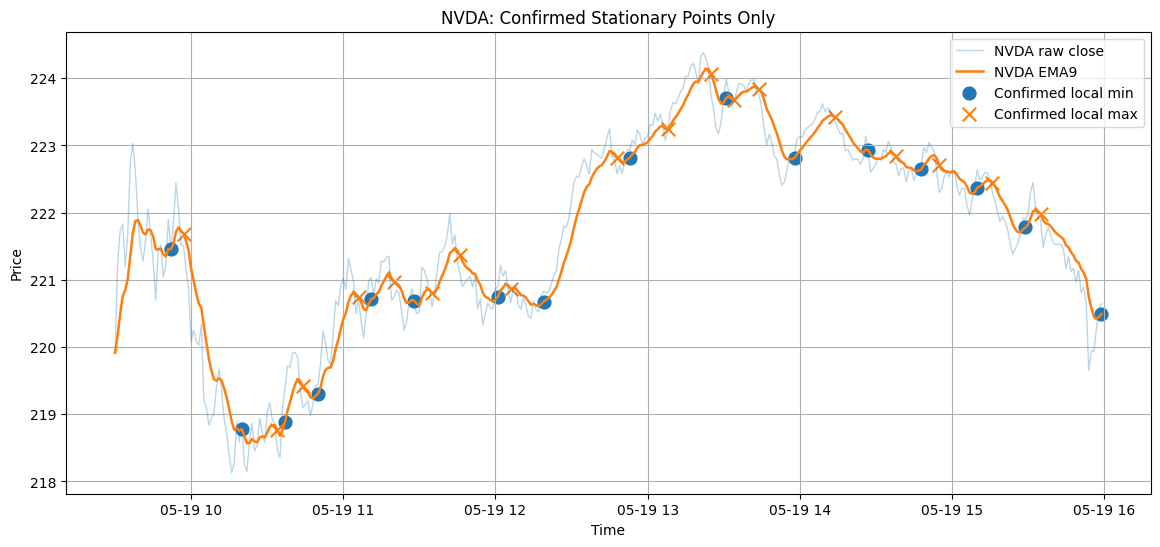

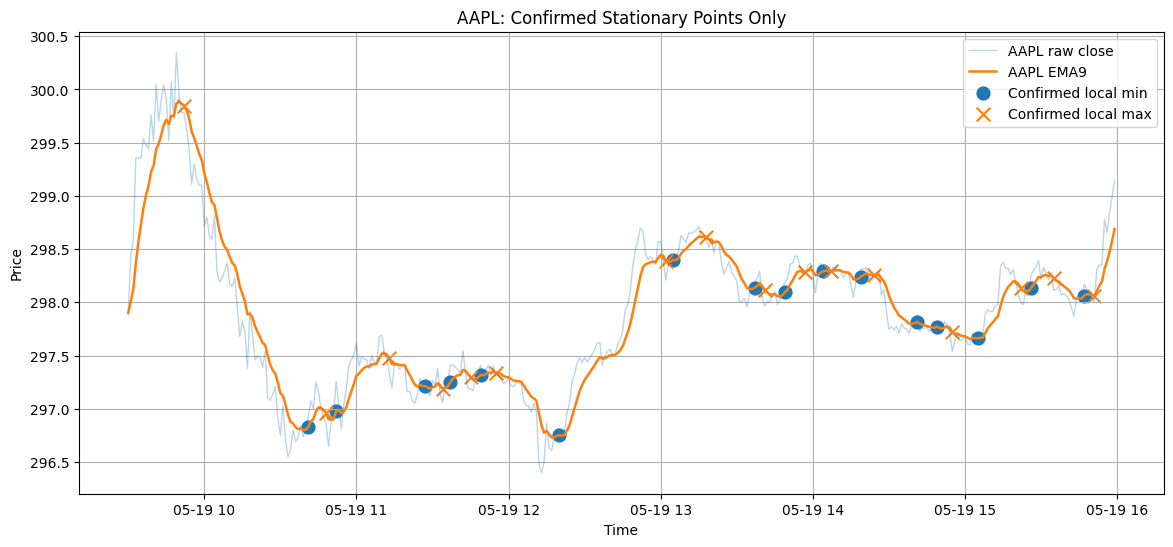

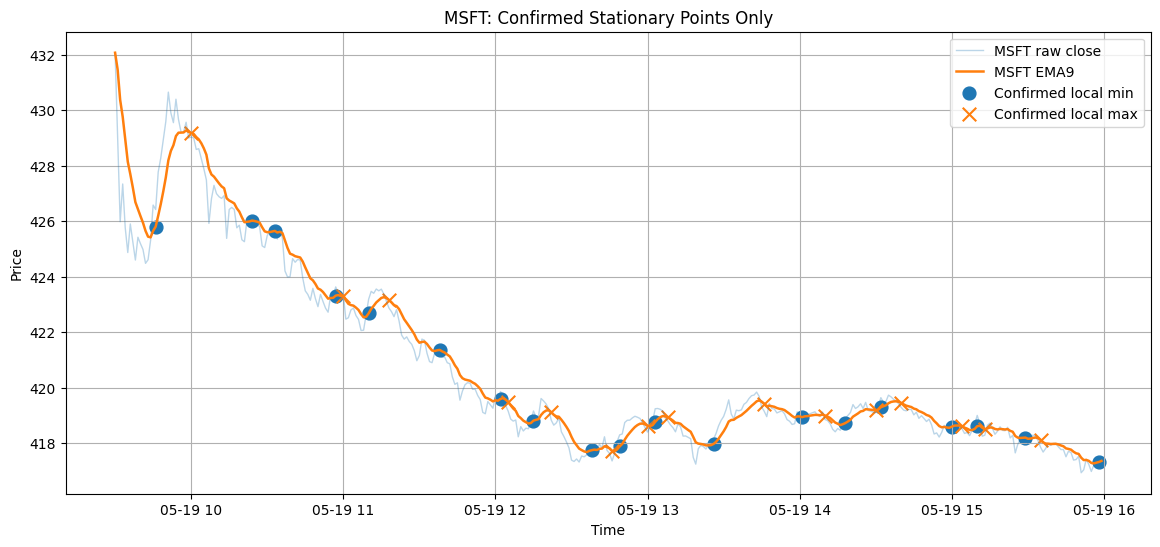

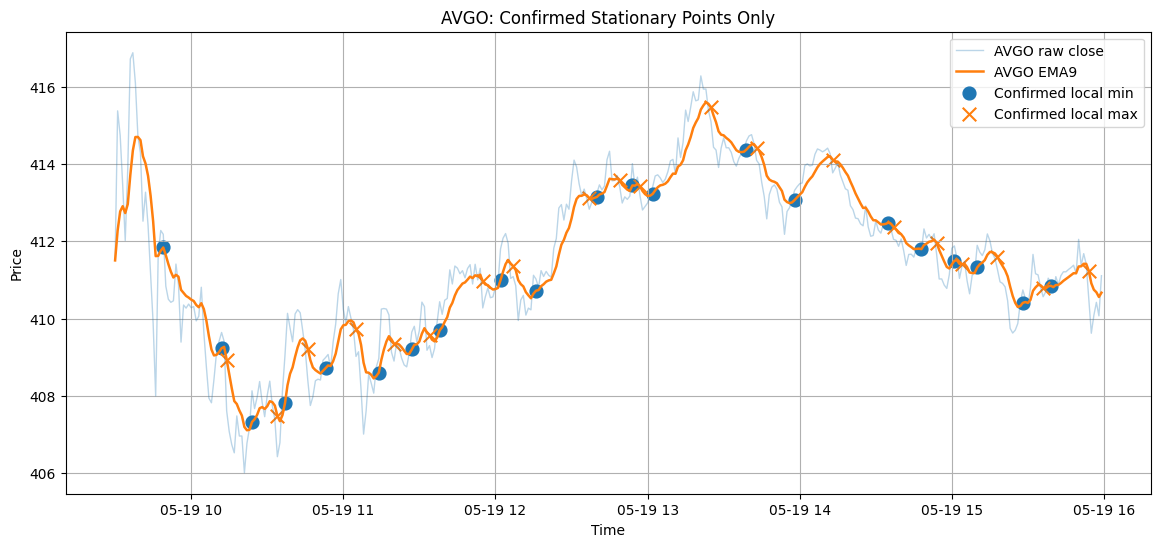

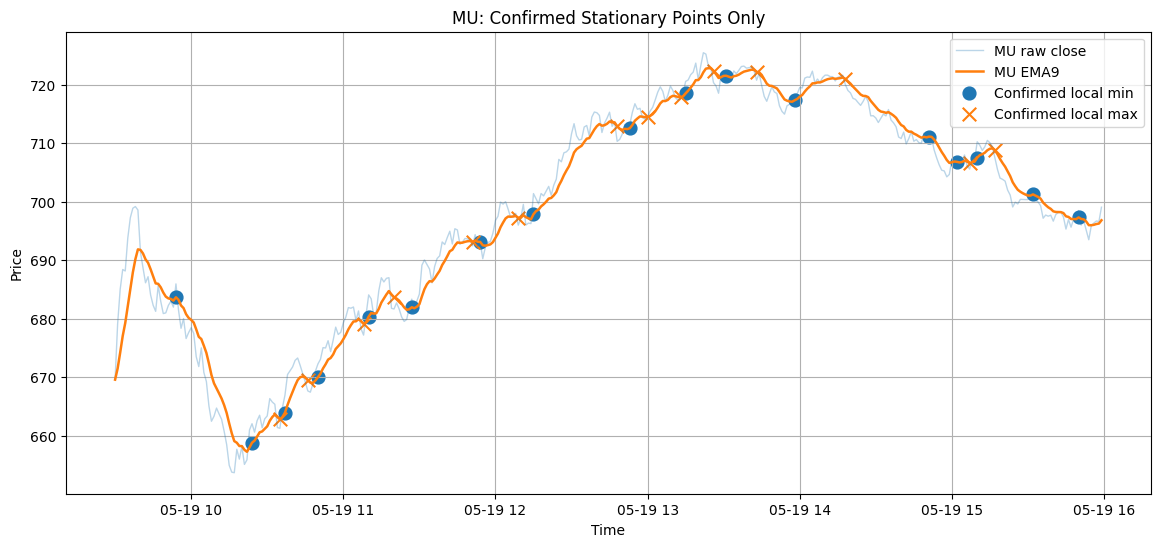

In [6]:
# ============================================================
# Cell 5 — Plot confirmed stationary points only
# ============================================================

def plot_confirmed_stationary_points(symbol):
    sub = signals_df[signals_df["symbol"] == symbol].copy()

    if sub.empty:
        print(f"No data for {symbol}")
        return

    conf_min = sub[sub["confirmed_local_min_cd"]]
    conf_max = sub[sub["confirmed_local_max_cd"]]

    plt.figure(figsize=(14, 6))

    plt.plot(
        sub["timestamp"],
        sub["close"],
        label=f"{symbol} raw close",
        linewidth=1.0,
        alpha=0.30
    )

    plt.plot(
        sub["timestamp"],
        sub["smooth_close"],
        label=f"{symbol} EMA{EMA_PRICE_SPAN}",
        linewidth=1.8
    )

    plt.scatter(
        conf_min["timestamp"],
        conf_min["smooth_close"],
        marker="o",
        s=85,
        label="Confirmed local min"
    )

    plt.scatter(
        conf_max["timestamp"],
        conf_max["smooth_close"],
        marker="x",
        s=95,
        label="Confirmed local max"
    )

    plt.title(f"{symbol}: Confirmed Stationary Points Only")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()


for sym in SYMBOLS:
    plot_confirmed_stationary_points(sym)

In [7]:
# ============================================================
# Cell 6 — Lookup tables and risk/allocation functions
# ============================================================

df = signals_df.copy()
df_indexed = df.set_index(["symbol", "timestamp"]).sort_index()

price_pivot = (
    df.pivot(index="timestamp", columns="symbol", values="close")
    .sort_index()
    .ffill()
)

all_times = list(price_pivot.index)


def clamp(x, low, high):
    return max(low, min(x, high))


def get_price(symbol, ts):
    try:
        price = price_pivot.loc[ts, symbol]
        if pd.isna(price):
            return np.nan
        return float(price)
    except KeyError:
        return np.nan


def get_row(symbol, ts):
    try:
        return df_indexed.loc[(symbol, ts)]
    except KeyError:
        return None


def calculate_atr_stop_loss_pct(row):
    if row is None:
        return None

    if pd.isna(row["atr"]) or row["atr"] <= 0:
        return None

    raw_stop_pct = (ATR_MULTIPLIER * float(row["atr"])) / float(row["close"])

    stop_loss_pct = clamp(
        raw_stop_pct,
        MIN_STOP_LOSS_PCT,
        MAX_STOP_LOSS_PCT
    )

    return stop_loss_pct


def calculate_signal_score(row):
    """
    Simple confirmed-min score.
    Early warnings are deliberately ignored.
    """
    if row is None or not bool(row["confirmed_local_min_cd"]):
        return 0.0

    score = 6.0

    # Stronger positive curvature means a cleaner turn.
    if row["curvature"] > MIN_ABS_CURVATURE:
        score += min(2.0, row["curvature"] / MIN_ABS_CURVATURE * 0.25)

    # Context bonus if price is above VWAP.
    if row["close"] > row["vwap"]:
        score += 1.0

    # Slight bonus if slope just turned up clearly.
    if row["slope"] > 0:
        score += 1.0

    return min(score, 10.0)


def signal_strength_factor(signal_score):
    """
    Smoothly maps signal score to allocation factor.
    """
    if signal_score < 6.0:
        return 0.0

    min_factor = 0.50
    max_factor = 1.00

    scaled = (signal_score - 6.0) / 4.0
    scaled = clamp(scaled, 0.0, 1.0)

    return min_factor + scaled * (max_factor - min_factor)


def current_stock_value(ts, positions):
    value = 0.0

    for symbol, pos in positions.items():
        price = get_price(symbol, ts)
        if not np.isnan(price):
            value += pos["qty"] * price

    return value


def current_equity(ts, cash, positions):
    return cash + current_stock_value(ts, positions)


def total_open_risk(positions):
    return sum(pos.get("risk_dollars", 0.0) for pos in positions.values())


def build_buy_candidates(ts, cash, positions):
    """
    Buy candidates are confirmed local minima only.
    """
    if ts > last_buy_time:
        return []

    if len(positions) >= MAX_OPEN_POSITIONS:
        return []

    candidates = []

    for symbol in SYMBOLS:
        if symbol in positions:
            continue

        row = get_row(symbol, ts)
        if row is None:
            continue

        if not bool(row["confirmed_local_min_cd"]):
            continue

        stop_loss_pct = calculate_atr_stop_loss_pct(row)
        if stop_loss_pct is None:
            continue

        signal_score = calculate_signal_score(row)
        signal_factor = signal_strength_factor(signal_score)

        if signal_factor <= 0:
            continue

        # Higher score + lower ATR/stop risk gets priority.
        allocation_weight = (signal_score * signal_factor) / stop_loss_pct

        candidates.append({
            "symbol": symbol,
            "timestamp": ts,
            "row": row,
            "signal_score": signal_score,
            "signal_factor": signal_factor,
            "stop_loss_pct": stop_loss_pct,
            "atr": float(row["atr"]),
            "allocation_weight": allocation_weight,
            "reason": "confirmed local min"
        })

    candidates = sorted(
        candidates,
        key=lambda x: x["allocation_weight"],
        reverse=True
    )

    return candidates[:MAX_NEW_BUYS_PER_MINUTE]


def allocate_cash_to_candidates(candidates, ts, cash, positions):
    if not candidates:
        return []

    equity = current_equity(ts, cash, positions)
    usable_cash = cash * (1 - CASH_BUFFER_FRACTION)

    if usable_cash < MIN_POSITION_VALUE:
        return []

    remaining_slots = MAX_OPEN_POSITIONS - len(positions)
    if remaining_slots <= 0:
        return []

    candidates = candidates[:remaining_slots]

    max_total_open_risk = equity * MAX_TOTAL_OPEN_RISK_PCT
    remaining_risk_budget = max_total_open_risk - total_open_risk(positions)

    if remaining_risk_budget <= 0:
        return []

    total_weight = sum(c["allocation_weight"] for c in candidates)
    if total_weight <= 0:
        return []

    max_position_value = equity * MAX_POSITION_FRACTION
    intended_risk_dollars = equity * RISK_PER_TRADE_PCT

    allocations = []

    for c in candidates:
        raw_allocation = usable_cash * (c["allocation_weight"] / total_weight)

        # ATR risk cap
        risk_capped_position = intended_risk_dollars / c["stop_loss_pct"]
        remaining_risk_capped_position = remaining_risk_budget / c["stop_loss_pct"]

        final_allocation = min(
            raw_allocation,
            max_position_value,
            risk_capped_position,
            remaining_risk_capped_position,
            usable_cash
        )

        final_allocation *= c["signal_factor"]

        if final_allocation < MIN_POSITION_VALUE:
            continue

        c = c.copy()
        c["raw_allocation"] = raw_allocation
        c["final_allocation"] = final_allocation
        c["intended_risk_dollars"] = intended_risk_dollars
        c["actual_risk_dollars"] = final_allocation * c["stop_loss_pct"]

        allocations.append(c)

    # Safety: never spend more than usable cash.
    total_allocated = sum(c["final_allocation"] for c in allocations)

    if total_allocated > usable_cash and total_allocated > 0:
        scale = usable_cash / total_allocated

        for c in allocations:
            c["final_allocation"] *= scale
            c["actual_risk_dollars"] = c["final_allocation"] * c["stop_loss_pct"]

    return allocations

In [8]:
# ============================================================
# Cell 7 — Backtest engine: sell phase, risk phase, buy phase
# ============================================================

cash = STARTING_CASH
positions = {}
trade_log = []
equity_curve = []


def buy_position(allocation):
    global cash, positions, trade_log

    symbol = allocation["symbol"]
    ts = allocation["timestamp"]
    row = allocation["row"]

    raw_price = float(row["close"])
    buy_price = raw_price * (1 + SLIPPAGE_RATE)

    position_value = min(allocation["final_allocation"], cash)

    if position_value < MIN_POSITION_VALUE:
        return

    qty = position_value / buy_price

    cash -= position_value

    positions[symbol] = {
        "symbol": symbol,
        "qty": qty,
        "entry_price": buy_price,
        "entry_time": ts,
        "cost": position_value,
        "stop_loss_pct": allocation["stop_loss_pct"],
        "stop_price": buy_price * (1 - allocation["stop_loss_pct"]),
        "risk_dollars": allocation["actual_risk_dollars"],
        "intended_risk_dollars": allocation["intended_risk_dollars"],
        "signal_score": allocation["signal_score"],
        "signal_factor": allocation["signal_factor"],
        "atr": allocation["atr"],
        "high_water": buy_price,
    }

    trade_log.append({
        "timestamp": ts,
        "symbol": symbol,
        "side": "BUY",
        "price": buy_price,
        "qty": qty,
        "value": position_value,
        "cash_after": cash,
        "reason": allocation["reason"],
        "signal_score": allocation["signal_score"],
        "signal_factor": allocation["signal_factor"],
        "stop_loss_pct": allocation["stop_loss_pct"],
        "stop_price": positions[symbol]["stop_price"],
        "risk_dollars": allocation["actual_risk_dollars"],
        "pnl": np.nan,
        "pnl_pct": np.nan
    })


def sell_position(symbol, ts, fraction, reason):
    global cash, positions, trade_log

    if symbol not in positions:
        return

    row = get_row(symbol, ts)
    if row is None:
        return

    raw_price = float(row["close"])
    sell_price = raw_price * (1 - SLIPPAGE_RATE)

    pos = positions[symbol]

    fraction = clamp(fraction, 0.0, 1.0)
    qty_to_sell = pos["qty"] * fraction

    if qty_to_sell <= 0:
        return

    proceeds = qty_to_sell * sell_price
    cost_basis_sold = pos["entry_price"] * qty_to_sell

    pnl = proceeds - cost_basis_sold
    pnl_pct = sell_price / pos["entry_price"] - 1

    cash += proceeds

    trade_log.append({
        "timestamp": ts,
        "symbol": symbol,
        "side": "SELL",
        "price": sell_price,
        "qty": qty_to_sell,
        "value": proceeds,
        "cash_after": cash,
        "reason": reason,
        "signal_score": pos.get("signal_score", np.nan),
        "signal_factor": pos.get("signal_factor", np.nan),
        "stop_loss_pct": pos.get("stop_loss_pct", np.nan),
        "stop_price": pos.get("stop_price", np.nan),
        "risk_dollars": pos.get("risk_dollars", np.nan),
        "pnl": pnl,
        "pnl_pct": pnl_pct
    })

    pos["qty"] -= qty_to_sell

    if pos["qty"] <= 1e-10 or fraction >= 0.999:
        del positions[symbol]
    else:
        pos["risk_dollars"] *= (1 - fraction)


def manage_sells(ts):
    """
    Sell phase happens before risk/buy phase.

    Sell all if:
    - stop-loss is hit,
    - end-of-day forced liquidation,
    - confirmed local max AND price >= entry * 1.004.
    """
    for symbol in list(positions.keys()):
        pos = positions[symbol]
        row = get_row(symbol, ts)

        if row is None:
            continue

        price = float(row["close"])
        pos["high_water"] = max(pos["high_water"], price)

        # 1. End-of-day liquidation
        if ts >= force_sell_time:
            sell_position(symbol, ts, 1.0, "forced end-of-day sell")
            continue

        # 2. Stop-loss
        if price <= pos["stop_price"]:
            sell_position(symbol, ts, 1.0, "ATR stop-loss hit")
            continue

        # 3. Confirmed local max profit rule
        if bool(row["confirmed_local_max_cd"]):
            required_sell_price = pos["entry_price"] * (1 + CONFIRMED_MAX_SELL_PROFIT_PCT)

            if price >= required_sell_price:
                sell_position(
                    symbol,
                    ts,
                    1.0,
                    "confirmed max + 0.4% profit, sell all"
                )
                continue


print("\nRunning Top 5 XLK stationary-point ATR backtest...")

for ts in all_times:
    # 1. SELL PHASE
    manage_sells(ts)

    # 2. RISK UPDATE PHASE
    # Recalculated implicitly through current_equity(), cash, and positions.

    # 3. BUY PHASE
    if len(positions) < MAX_OPEN_POSITIONS:
        candidates = build_buy_candidates(ts, cash, positions)
        allocations = allocate_cash_to_candidates(candidates, ts, cash, positions)

        for allocation in allocations:
            if len(positions) >= MAX_OPEN_POSITIONS:
                break

            buy_position(allocation)

    # 4. Track portfolio
    stock_value = current_stock_value(ts, positions)
    total_equity = cash + stock_value

    equity_curve.append({
        "timestamp": ts,
        "cash": cash,
        "stock_value": stock_value,
        "equity": total_equity,
        "open_positions": len(positions),
        "open_symbols": ",".join(sorted(positions.keys()))
    })


# Final liquidation, just in case anything remains open.
final_ts = all_times[-1]

for symbol in list(positions.keys()):
    sell_position(symbol, final_ts, 1.0, "final liquidation")

equity_curve.append({
    "timestamp": final_ts,
    "cash": cash,
    "stock_value": 0.0,
    "equity": cash,
    "open_positions": 0,
    "open_symbols": ""
})

equity_df = pd.DataFrame(equity_curve).drop_duplicates("timestamp").set_index("timestamp")
trades_df = pd.DataFrame(trade_log)

print("Backtest complete.")
print(f"Number of trades: {len(trades_df)}")
display(trades_df.head())


Running Top 5 XLK stationary-point ATR backtest...
Backtest complete.
Number of trades: 28


,timestamp,symbol,side,price,qty,value,cash_after,reason,signal_score,signal_factor,stop_loss_pct,stop_price,risk_dollars,pnl,pnl_pct
0,2026-05-19 10:12:00-04:00,AVGO,BUY,409.721928,0.800848,328.125000,1171.875000,confirmed local min,9.0,0.875,0.006,407.263596,1.968750,NaN,NaN
1,2026-05-19 10:15:00-04:00,AVGO,SELL,406.998584,0.800848,325.944015,1497.819015,ATR stop-loss hit,9.0,0.875,0.006,407.263596,1.968750,-2.180985,-0.006647
2,2026-05-19 10:20:00-04:00,NVDA,BUY,218.918775,1.496664,327.647910,1170.171106,confirmed local min,9.0,0.875,0.006,217.605262,1.965887,NaN,NaN
3,2026-05-19 10:24:00-04:00,MSFT,BUY,426.235230,0.768665,327.631941,842.539165,confirmed local min,9.0,0.875,0.006,423.677819,1.965792,NaN,NaN
4,2026-05-19 10:24:00-04:00,AVGO,BUY,408.211626,0.802603,327.631941,514.907224,confirmed local min,9.0,0.875,0.006,405.762356,1.965792,NaN,NaN


In [9]:
# ============================================================
# Cell 8 — Results and profit summary
# ============================================================

final_equity = equity_df["equity"].iloc[-1]
total_profit = final_equity - STARTING_CASH
total_return = final_equity / STARTING_CASH - 1

equity_df["running_max"] = equity_df["equity"].cummax()
equity_df["drawdown"] = equity_df["equity"] / equity_df["running_max"] - 1
max_drawdown = equity_df["drawdown"].min()

if not trades_df.empty:
    sell_trades = trades_df[trades_df["side"] == "SELL"].copy()
else:
    sell_trades = pd.DataFrame()

if not sell_trades.empty:
    realised_pnl = sell_trades["pnl"].sum()
    win_rate = (sell_trades["pnl"] > 0).mean()
    avg_win = sell_trades.loc[sell_trades["pnl"] > 0, "pnl"].mean()
    avg_loss = sell_trades.loc[sell_trades["pnl"] <= 0, "pnl"].mean()
    gross_profit = sell_trades.loc[sell_trades["pnl"] > 0, "pnl"].sum()
    gross_loss = -sell_trades.loc[sell_trades["pnl"] <= 0, "pnl"].sum()
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
else:
    realised_pnl = 0.0
    win_rate = np.nan
    avg_win = np.nan
    avg_loss = np.nan
    gross_profit = 0.0
    gross_loss = 0.0
    profit_factor = np.nan

# Equal-weight buy-and-hold benchmark
benchmark_curve = pd.Series(0.0, index=equity_df.index)

valid_symbols = [
    sym for sym in SYMBOLS
    if sym in price_pivot.columns and not price_pivot[sym].dropna().empty
]

per_stock_start_value = STARTING_CASH / len(valid_symbols)

for sym in valid_symbols:
    s = price_pivot[sym].reindex(equity_df.index).ffill()
    first_valid = s.dropna().iloc[0]
    benchmark_curve += per_stock_start_value * (s / first_valid)

benchmark_final = benchmark_curve.iloc[-1]
benchmark_profit = benchmark_final - STARTING_CASH
benchmark_return = benchmark_final / STARTING_CASH - 1

print("\n================ BACKTEST RESULTS ================")
print(f"Date:                      {target_day}")
print(f"Symbols:                   {SYMBOLS}")
print(f"Starting cash:             ${STARTING_CASH:,.2f}")
print(f"Final portfolio value:     ${final_equity:,.2f}")
print(f"Total profit accumulated:  ${total_profit:,.2f}")
print(f"Bot return:                {total_return:.2%}")
print(f"Benchmark final value:     ${benchmark_final:,.2f}")
print(f"Benchmark profit:          ${benchmark_profit:,.2f}")
print(f"Benchmark return:          {benchmark_return:.2%}")
print(f"Max drawdown:              {max_drawdown:.2%}")
print(f"Realised PnL from sells:   ${realised_pnl:,.2f}")
print(f"Number of trades:          {len(trades_df)}")
print(f"Number of sells:           {len(sell_trades)}")

if not sell_trades.empty:
    print(f"Win rate:                  {win_rate:.2%}")
    print(f"Average win:               ${avg_win:.2f}" if not pd.isna(avg_win) else "Average win:               N/A")
    print(f"Average loss:              ${avg_loss:.2f}" if not pd.isna(avg_loss) else "Average loss:              N/A")
    print(f"Profit factor:             {profit_factor:.2f}")

if not sell_trades.empty:
    print("\nPnL by symbol:")
    display(
        sell_trades
        .groupby("symbol")["pnl"]
        .agg(["count", "sum", "mean"])
        .sort_values("sum", ascending=False)
    )

    print("\nSell reason counts:")
    display(sell_trades["reason"].value_counts())


================ BACKTEST RESULTS ================
Date:                      2026-05-19
Symbols:                   ['NVDA', 'AAPL', 'MSFT', 'AVGO', 'MU']
Starting cash:             $1,500.00
Final portfolio value:     $1,509.51
Total profit accumulated:  $9.51
Bot return:                0.63%
Benchmark final value:     $1,505.06
Benchmark profit:          $5.06
Benchmark return:          0.34%
Max drawdown:              -0.55%
Realised PnL from sells:   $9.51
Number of trades:          28
Number of sells:           14
Win rate:                  57.14%
Average win:               $2.61
Average loss:              $-1.90
Profit factor:             1.84

PnL by symbol:


,count,sum,mean
symbol,,,
MU,4,12.575880,3.143970
NVDA,3,2.830036,0.943345
AAPL,1,1.385074,1.385074
AVGO,3,-1.623995,-0.541332
MSFT,3,-5.654883,-1.884961



Sell reason counts:


reason
confirmed max + 0.4% profit, sell all    7
ATR stop-loss hit                        4
forced end-of-day sell                   3
Name: count, dtype: int64

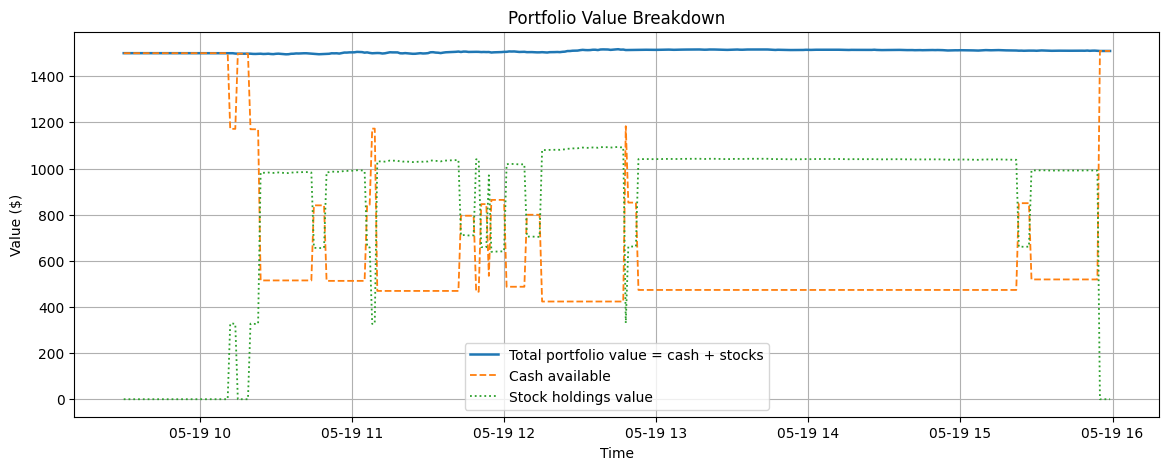

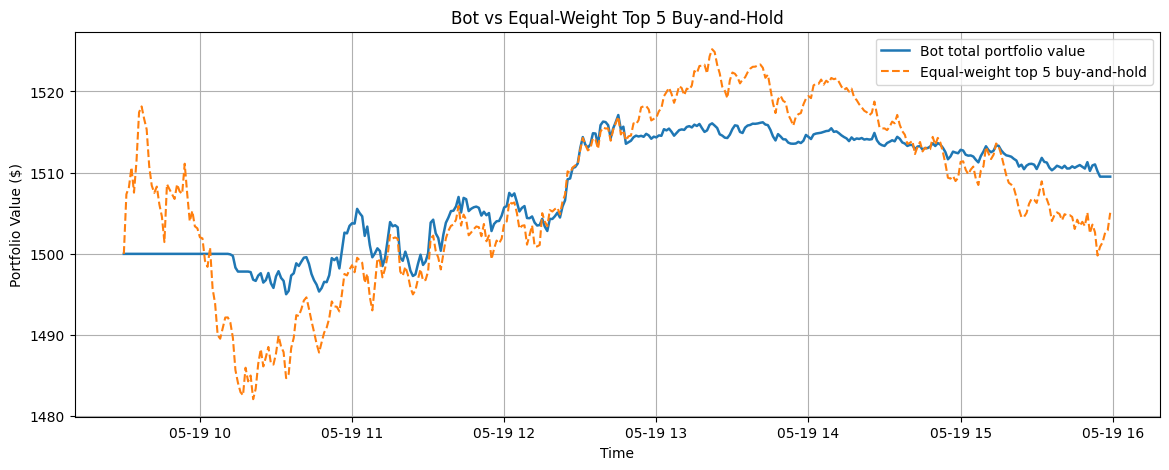

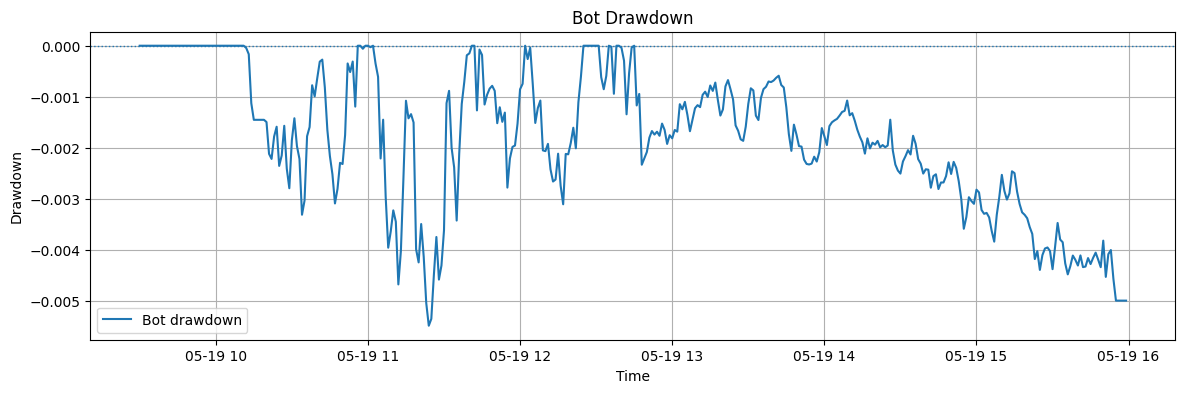

In [10]:
# ============================================================
# Cell 9 — Portfolio value plots
# Includes total portfolio, stock holdings, and cash
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    equity_df.index,
    equity_df["equity"],
    label="Total portfolio value = cash + stocks",
    linewidth=1.8
)

plt.plot(
    equity_df.index,
    equity_df["cash"],
    label="Cash available",
    linewidth=1.3,
    linestyle="--"
)

plt.plot(
    equity_df.index,
    equity_df["stock_value"],
    label="Stock holdings value",
    linewidth=1.3,
    linestyle=":"
)

plt.title("Portfolio Value Breakdown")
plt.xlabel("Time")
plt.ylabel("Value ($)")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 5))

plt.plot(
    equity_df.index,
    equity_df["equity"],
    label="Bot total portfolio value",
    linewidth=1.8
)

plt.plot(
    benchmark_curve.index,
    benchmark_curve,
    label="Equal-weight top 5 buy-and-hold",
    linewidth=1.5,
    linestyle="--"
)

plt.title("Bot vs Equal-Weight Top 5 Buy-and-Hold")
plt.xlabel("Time")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 4))

plt.plot(
    equity_df.index,
    equity_df["drawdown"],
    label="Bot drawdown",
    linewidth=1.5
)

plt.axhline(0, linestyle=":", linewidth=1)

plt.title("Bot Drawdown")
plt.xlabel("Time")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

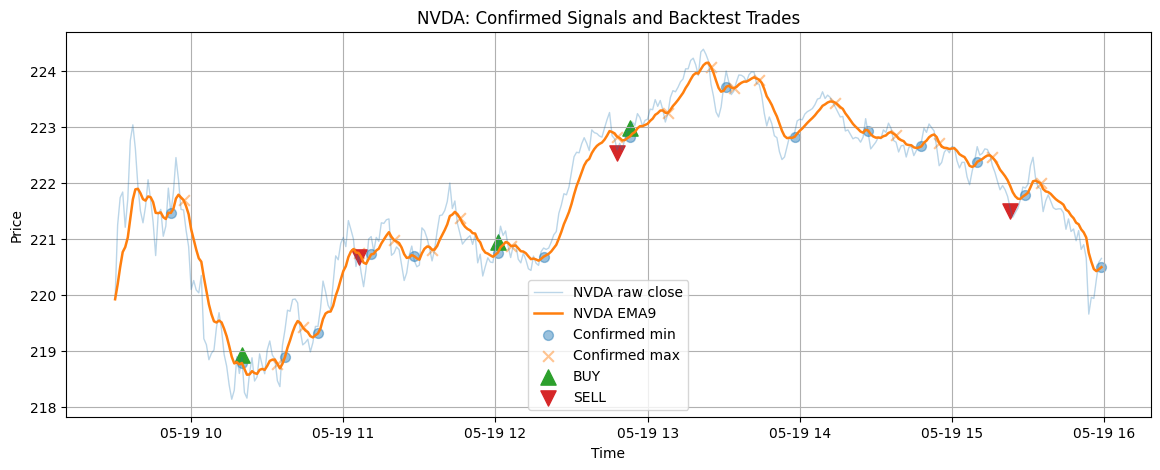

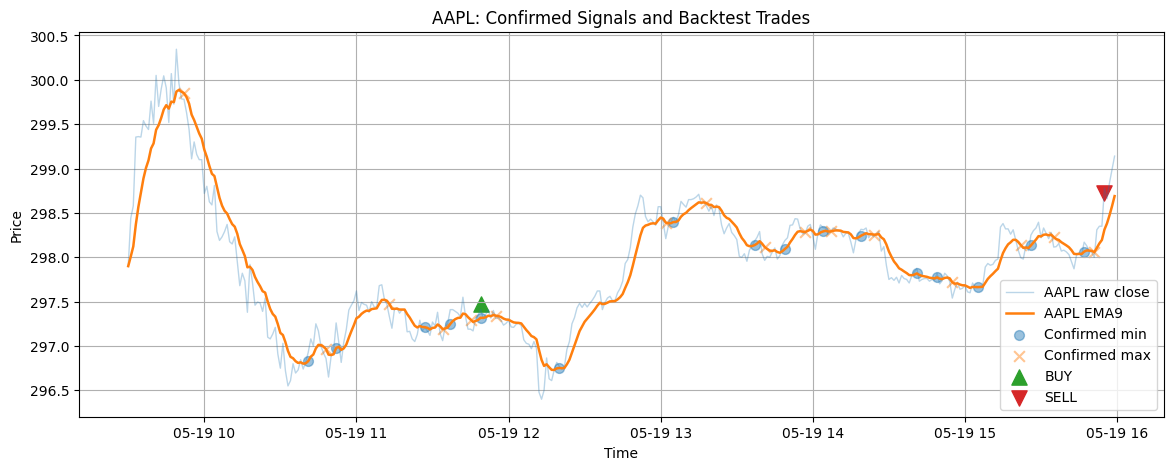

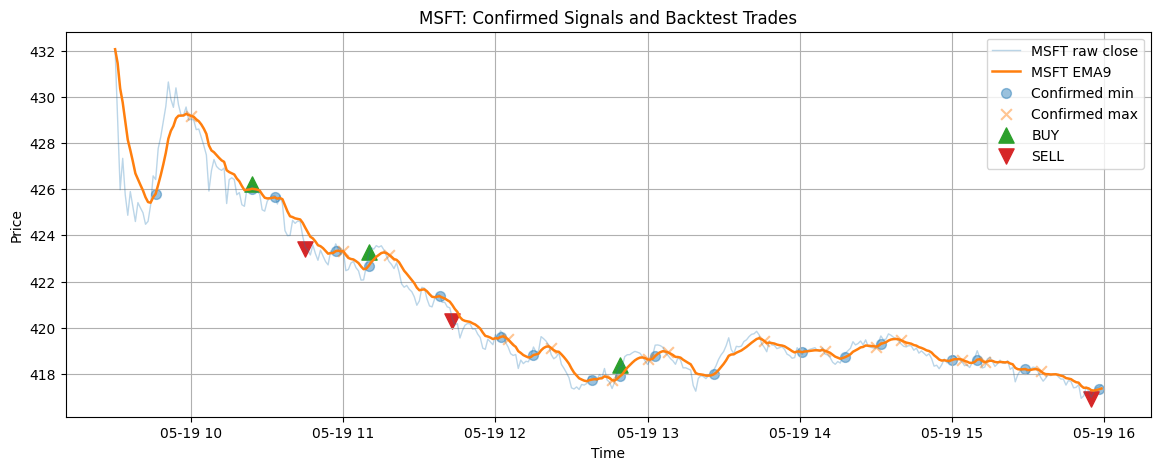

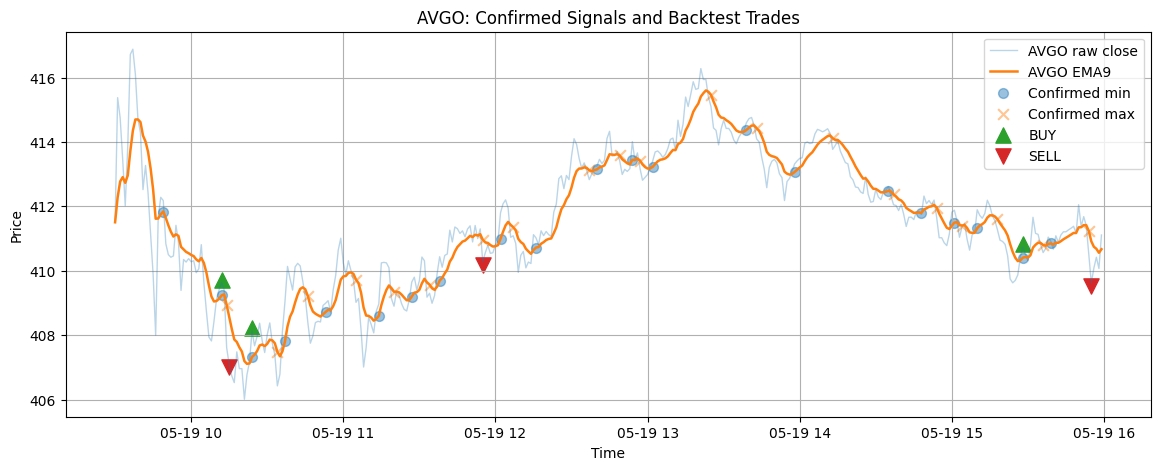

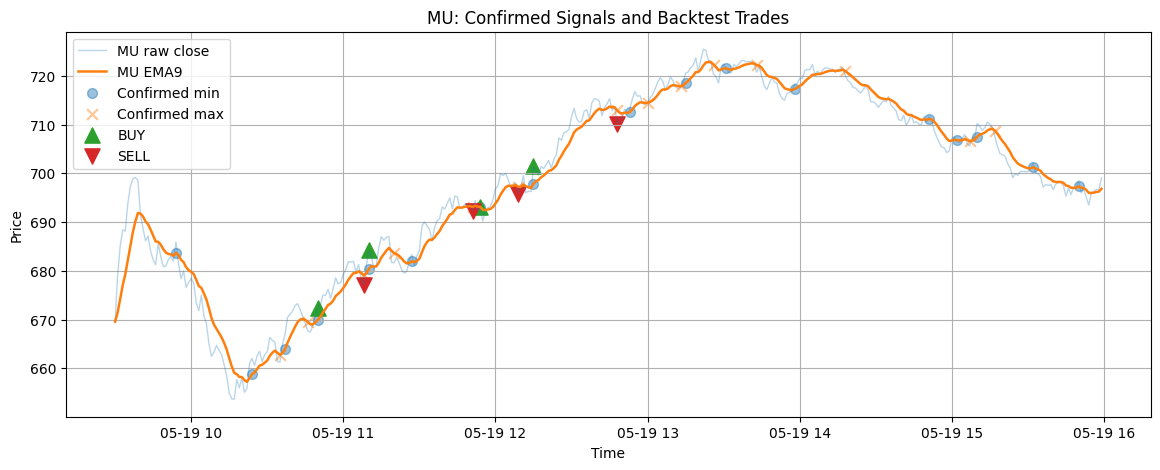

In [11]:
# ============================================================
# Cell 10 — Buy/sell markers per stock
# ============================================================

buy_trades = trades_df[trades_df["side"] == "BUY"].copy() if not trades_df.empty else pd.DataFrame()
sell_trades = trades_df[trades_df["side"] == "SELL"].copy() if not trades_df.empty else pd.DataFrame()

for sym in SYMBOLS:
    sub = df[df["symbol"] == sym].copy()

    if sub.empty:
        continue

    buys = buy_trades[buy_trades["symbol"] == sym].copy() if not buy_trades.empty else pd.DataFrame()
    sells = sell_trades[sell_trades["symbol"] == sym].copy() if not sell_trades.empty else pd.DataFrame()

    plt.figure(figsize=(14, 5))

    plt.plot(
        sub["timestamp"],
        sub["close"],
        label=f"{sym} raw close",
        linewidth=1.0,
        alpha=0.30
    )

    plt.plot(
        sub["timestamp"],
        sub["smooth_close"],
        label=f"{sym} EMA{EMA_PRICE_SPAN}",
        linewidth=1.8
    )

    # Confirmed min/max background markers
    conf_min = sub[sub["confirmed_local_min_cd"]]
    conf_max = sub[sub["confirmed_local_max_cd"]]

    plt.scatter(
        conf_min["timestamp"],
        conf_min["smooth_close"],
        marker="o",
        s=50,
        alpha=0.45,
        label="Confirmed min"
    )

    plt.scatter(
        conf_max["timestamp"],
        conf_max["smooth_close"],
        marker="x",
        s=60,
        alpha=0.45,
        label="Confirmed max"
    )

    if not buys.empty:
        plt.scatter(
            buys["timestamp"],
            buys["price"],
            marker="^",
            s=120,
            label="BUY"
        )

    if not sells.empty:
        plt.scatter(
            sells["timestamp"],
            sells["price"],
            marker="v",
            s=120,
            label="SELL"
        )

    plt.title(f"{sym}: Confirmed Signals and Backtest Trades")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
# ============================================================
# Cell 11 — Save outputs
# ============================================================

out_trade_file = f"top5_xlk_atr_stationary_backtest_trades_{target_day}.csv"
out_equity_file = f"top5_xlk_atr_stationary_backtest_equity_{target_day}.csv"
out_signal_file = f"top5_xlk_atr_stationary_backtest_signals_{target_day}.csv"

trades_df.to_csv(out_trade_file, index=False)
equity_df.to_csv(out_equity_file)
df.to_csv(out_signal_file, index=False)

print(f"Saved trades to: {out_trade_file}")
print(f"Saved equity curve to: {out_equity_file}")
print(f"Saved signal file to: {out_signal_file}")

Saved trades to: top5_xlk_atr_stationary_backtest_trades_2026-05-19.csv
Saved equity curve to: top5_xlk_atr_stationary_backtest_equity_2026-05-19.csv
Saved signal file to: top5_xlk_atr_stationary_backtest_signals_2026-05-19.csv
